# Deforestation in Harz Mountain Region
## Introduction
Harz National Park and its surrounding environment has suffered an infestation of bark beetles over the past decade. This has led to the widespread loss of the native Norway spruce population. The purpose of this study is to examine the effects of this beetle on the loss of forest and the level of species diveristy within the area.  

To accomplish this, remote sensing data is gathered from the EOPF provided by Copernicus, an association of the European Space Agency. EOPF is intended to be a centralized and convenient cloud platform for researchers that focuses on cloud-native formats such as the ZARR file format. This notebook extensively uses both the cloud data resources as well as the ZARR file format.

### Literature Review

#### Modules
There are a variety of helper functions that are organized into three modules:  
- `modules.utils`: Miscellaneous data processing
- `modules.data_load`: Convenience functions for loading data from EOPF
- `modules.monoculture`: Calculation functions for sprectral analysis

#### Study Area
The study area is focused around the region of Harz National Park. Initial work was performed using the exact bounding box of the park, but has since been moved to cover other areas within the vicinity.

### Initialization and Setup

In [ ]:
import warnings
import os
import sys
import logging
from pathlib import Path

sys.path.append(str(Path(os.getcwd()).parent))
warnings.filterwarnings("ignore", category=DeprecationWarning, module="pystac")

from shapely import geometry
from pystac_client import Client
import geopandas as gpd
from distributed import LocalCluster
import matplotlib.pyplot as plt

import pandas as pd
import xarray as xr
import zarr
import dask.array as da

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

### Own modules
from modules.utils import to_km2
from modules.data_load import (
    get_epsg_from_first_band,
    load_sentinel_data,
    load_sentinel_scl,
)
from modules.monoculture import (
    spectral_spatial_std,
    spectral_entropy,
    ndvi_texture,
    forest_monoculture_index,
    spectral_texture,
)


logging.basicConfig()
logger = logging.getLogger(__name__)

In [136]:
# Create local processing cluster
cluster = LocalCluster()
client = cluster.get_client()

/Users/jpwhex/Workspace/harz-deforestation-eopf/.venv/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 57616 instead
  warnings.warn(


In [137]:

harz_boundaries = gpd.read_file("../resources/Nationalpark_Harz_boundaries.geojson")
#bbox = harz_boundaries.geometry.values[0].bounds
bbox = [10.563869,51.773247,10.672531,51.832339]

bbox_polygon = geometry.box(*bbox)
polygon = gpd.GeoDataFrame(index=[0], crs="epsg:4326", geometry=[bbox_polygon])

In [138]:
catalog = Client.open("https://stac.core.eopf.eodc.eu")

### Loading and Preparing Data
Data from Sentinel-2-l2a is used for the analysis in this project. 10 and 20 meter resolutions are requested for surface reflectance observations, while the scene classification is requested in 20 meter resolution.  
The process of loading the data is quite straight-forward. For each year, the image with the least cloud cover is queried via the EOPF STAC-client. Then, the data is downloaded in the `eopf-zarr` format and then opened with `xarray`. A corresponding time dimension is added to the dataset at this point. Then, all the data is combined into a data-cube along the time dimension.

In [139]:
START_YEAR = 2015
END_YEAR = 2024
years = range(START_YEAR, END_YEAR)

In [140]:
# Visualization colormap

cmap = mcolors.ListedColormap(["#2c7bb6", "#d7191c"])
bounds = [-0.5, 0.5, 1.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

In [141]:
r10m = load_sentinel_data(
    catalog=catalog,
    years=years,
    bbox=bbox,
    collection="sentinel-2-l2a",
    asset="SR_10m",
    max_cloud_cover=30
)

In [142]:
r20m = load_sentinel_data(
    catalog=catalog,
    years=years,
    bbox=bbox,
    collection="sentinel-2-l2a",
    asset="SR_20m",
    max_cloud_cover=30
)

In [143]:
scl20m = load_sentinel_scl(
    catalog=catalog,
    years=years,
    bbox=bbox,
    collection="sentinel-2-l2a",
    asset="SCL_20m",
    max_cloud_cover=30
)

In [144]:
epsg = get_epsg_from_first_band(r10m)

bbox_reproj = polygon.to_crs("epsg:" + str(epsg)).geometry.values[0].bounds

x_slice = slice(bbox_reproj[0], bbox_reproj[2])  # ~100 pixels
y_slice = slice(bbox_reproj[3], bbox_reproj[1])  # ~100 pixels

#### Data Combination & Time Series
Search for data from June 1 to August 30 for every year in the study (2015-2024). Filter for images with less than 30% cloud cover, and pick the least cloudy item. Iterate through each item and load the scene classification layer at 20 meter resolution. Convert ZARR to xarray DataArray and add the time dimension.  
In the end, this approach was dropped in favor of a direct analysis of surface reflectance.

#### Reflectances & NDVI
Calculate the NDVI based off the data of the 10 meter reflectance observations. Filter for cloudless observations and calculate the yearly average for a given location.

In [145]:
from datetime import datetime

# Stack bands and NDVI, scale to match Sentinel Hub
# Not sure if we need to concat in this way? can keep it as data arrays in the dataset may be here??
reflectances_r10m = r10m

reflectances_r10m["ndvi"] = (reflectances_r10m.b08 - reflectances_r10m.b04) / (reflectances_r10m.b08 + reflectances_r10m.b04)

cloudless_bands_ndvi = reflectances_r10m.sel(
    time=datetime(2018, 6, 4), method="nearest"
)

region = cloudless_bands_ndvi.sel(x=x_slice, y=y_slice).chunk(
    {"y": "auto", "x": "auto"}
)

ndvi_region = region["ndvi"].compute()

yearly_ds = (
    reflectances_r10m.sel(x=x_slice, y=y_slice)
    .groupby("time.year")
    .mean(dim="time", skipna=True)
)

/Users/jpwhex/Workspace/harz-deforestation-eopf/.venv/lib/python3.12/site-packages/dask/_task_spec.py:759: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)


Taking a first look at the relevant image, it revolves around a mountain with lots of greenery around and on it. |

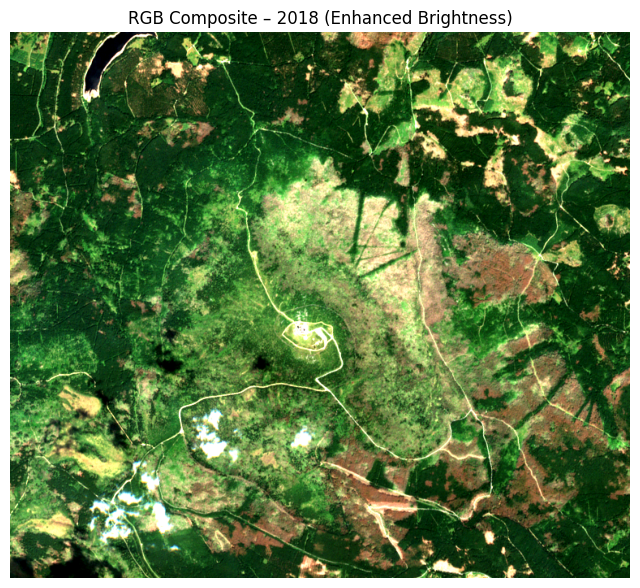

In [146]:
# Select yearly mean for 2018
rgb_2018 = yearly_ds.sel(year=2018)

# Stack RGB bands
rgb = xr.concat(
    [
        rgb_2018.b04,  # Red
        rgb_2018.b03,  # Green
        rgb_2018.b02,  # Blue
    ],
    dim="band"
).assign_coords(band=["R", "G", "B"])

# Percentile stretch (Sentinel Hub–like)
p2 = rgb.quantile(0.02)
p98 = rgb.quantile(0.98)

rgb_plot = (rgb - p2) / (p98 - p2)
rgb_plot = rgb_plot.clip(0, 1)

# Plot
plt.figure(figsize=(8, 8))
plt.imshow(rgb_plot.transpose("y", "x", "band"))
plt.title("RGB Composite – 2018 (Enhanced Brightness)")
plt.axis("off")
plt.show()


# NDVI-Values over the years
Taking a look at the NDVI-Values for the area of interest, we can clearly see the decline in forestry in part of the area. 
The important part for us is: There is not a steady decline everywhere, but just in a few areas, while other areas feel like they might be excluded.

/Users/jpwhex/Workspace/harz-deforestation-eopf/.venv/lib/python3.12/site-packages/dask/_task_spec.py:759: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)


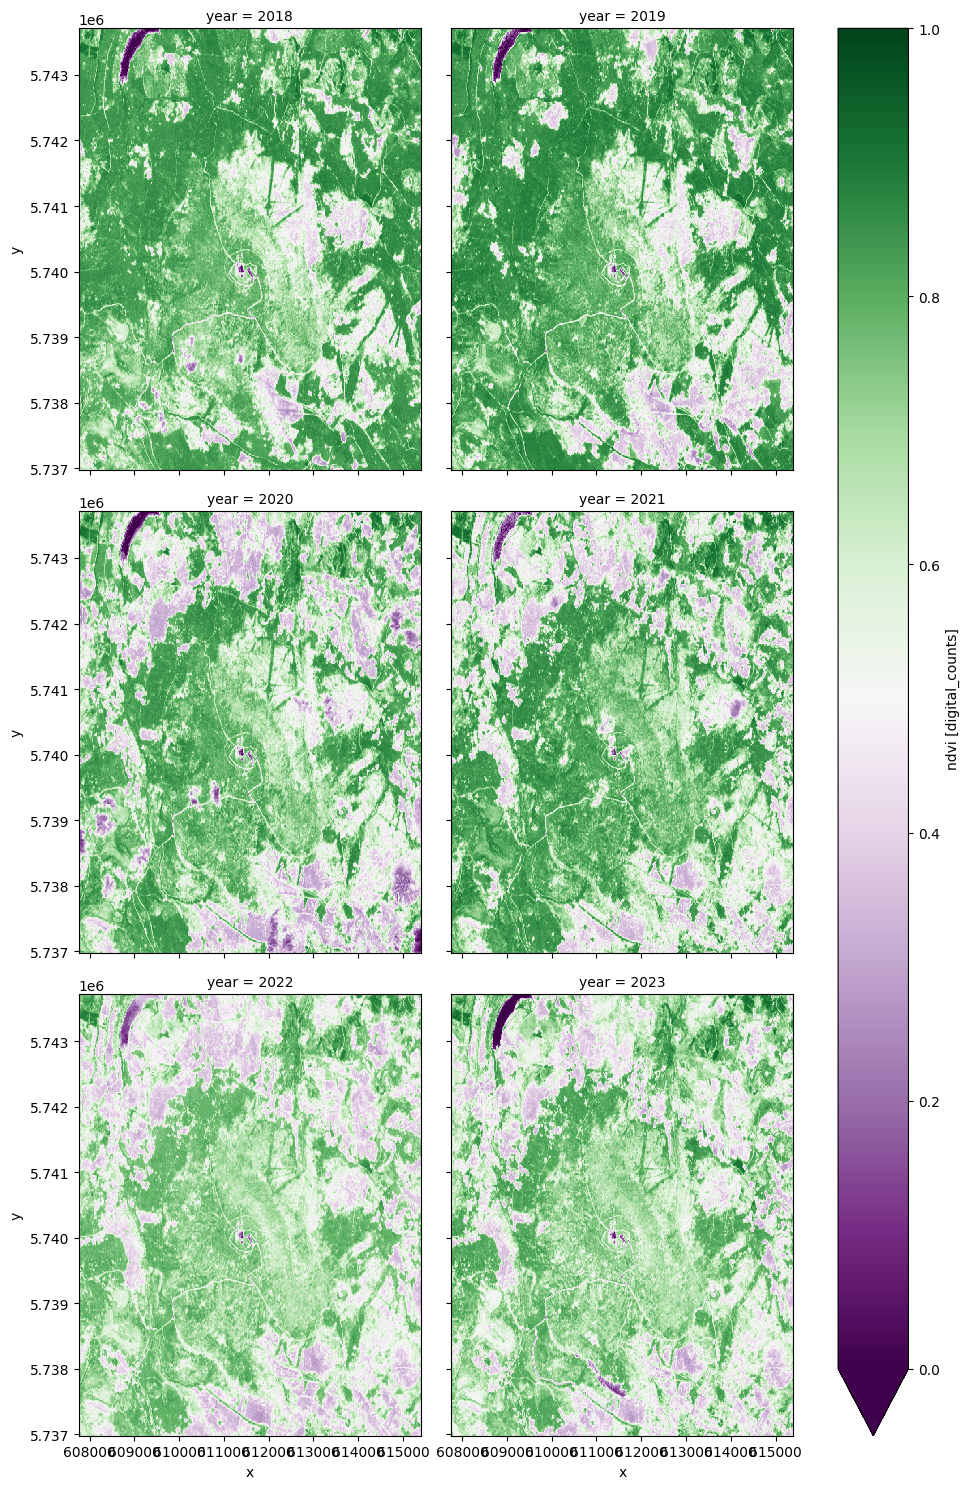

In [147]:
ndvi_yearly = yearly_ds["ndvi"].sel(x=x_slice, y=y_slice).sel(
    year=slice(START_YEAR, END_YEAR)
)

ndvi_yearly.plot(
    cmap="PRGn", x="x", y="y", col="year", col_wrap=2, vmin=0, vmax=1, figsize=(10, 15)
)

## Analysis

### Forest Cover
Calculate the forest cover by filtering pixels with NDVI greater that 0.7. Compare the resulting areas across years to find the loss of forest coverage. Visualize the loss with image comparison and a trendline.

In [148]:
yearly_ds.ndvi.load()
yearly_ds["FOREST"] = yearly_ds.ndvi > 0.7


#TODO: Remove resolution variable in favor of slice-size
resolution = (100, 100)
forest_pixels = yearly_ds.sel(x=x_slice, y=y_slice).FOREST.sum(["x", "y"])
forest_area_km2 = to_km2(forest_pixels, resolution)

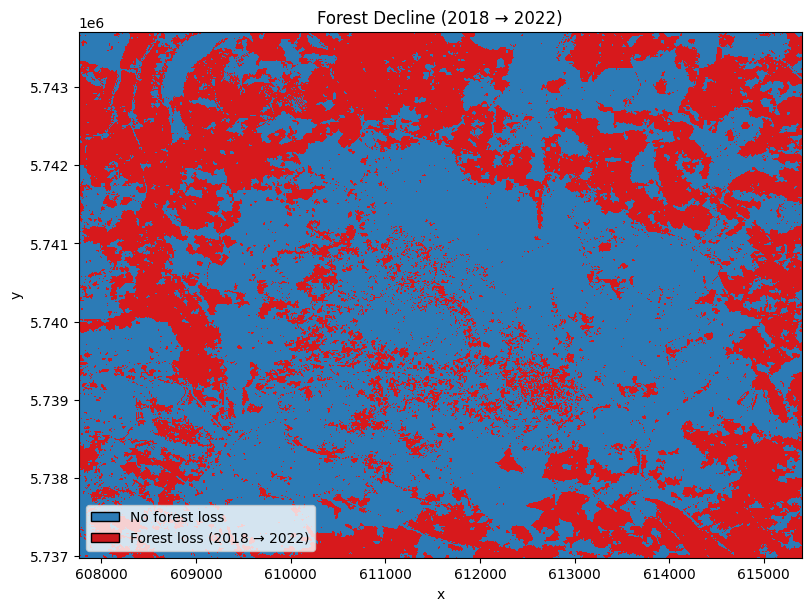

In [149]:
forest_2018 = yearly_ds.FOREST.sel(year=2018)
forest_2022 = yearly_ds.FOREST.sel(year=2022)

# Areas that were forest in 2018 but not in 2022
forest_decline = forest_2018 & (~forest_2022)

# Legend entries
legend_elements = [
    Patch(facecolor="#2c7bb6", edgecolor="black", label="No forest loss"),
    Patch(facecolor="#cb181d", edgecolor="black", label="Forest loss (2018 → 2022)")
]

fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

forest_decline.plot(
    ax=ax,
    cmap=cmap,
    norm=norm,
    add_colorbar=False
)

ax.set_title("Forest Decline (2018 → 2022)")
ax.legend(
    handles=legend_elements,
    loc="lower left",
    frameon=True
)

plt.show()


Taking a look at the percentage cover, it shows the steady decline towards the year 2022. 

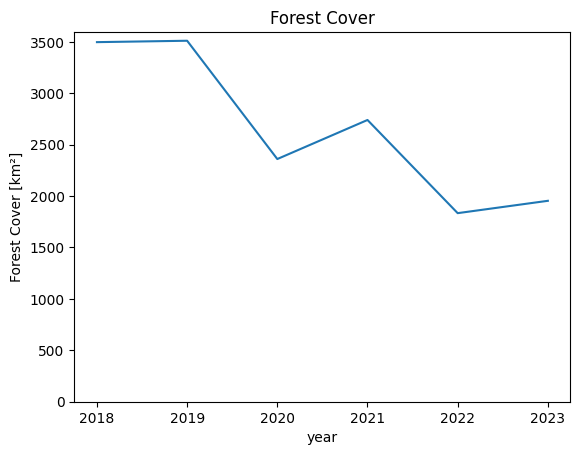

In [150]:
forest_area_km2.load() #Lazy loading
forest_area_km2.plot()

plt.title("Forest Cover")
plt.ylabel("Forest Cover [km²]")
plt.ylim(0);

### Variance Computing for detecting monoculture
Calculate the NDVI variance over time to estimate the likeliness of a monoculture at a point. If the NDVI does not vary over time, it is likely a monoculture. Conversely, a high variance can signal the presence of more diverse vegetation.  
Spatial variance is computed as well as temporal variance.

In [151]:
ndvi = yearly_ds["ndvi"].sel(x=x_slice, y=y_slice).sel(
    year=2021)

ndvi_var = (
    ndvi
    .rolling(x=5, y=5, center=True)
    .var()
)
ndvi_mean = (
    ndvi
    .rolling(x=5, y=5, center=True)
    .mean()
)

ndvi_cv = ndvi_var / ndvi_mean #Normalized with mean


#TODO: Aggregate over time? Probably even get better results in winter, because the trees might not be obstructing? What would we take then instead of NDVI? --> Take more than one image.


monoculture_mask = ndvi_cv < 0.05 #Example


#Different Windows to get a better view on uniformity

cv_3 = ndvi.rolling(x=3, y=3, center=True).var() / ndvi.rolling(x=3, y=3, center=True).mean()
cv_7 = ndvi.rolling(x=7, y=7, center=True).var() / ndvi.rolling(x=7, y=7, center=True).mean()

cv_combined = (cv_3 + cv_7) / 2

#### Spatial Variance and Texture
We want to determine the monoculture from per pixel NDVI. For how we are going to do this, we are going to take a further look at the theory behind these steps. 

## Spectral Spatial Standard Deviation
- Spectral spatial standard deviation quantifies how much reflectance values vary within a spatial window 
- Value Interpretation
  - Low std -> pixels are spectrally similar -> Monoculture
  - High std -> pixels are spectrally diverse -> Mixed forests

##### Sources
- Lausch et al. (2015) – Satellite remote sensing to monitor species diversity
https://hal.science/hal-01330160v1/document

#### NDVI Texture
NDVI texture analyzes spatial variation of NDVI rather than mean NDVI itself. Mean NDVI can be high in both monocultures and diverse forests — texture reveals structural diversity.
- Value Interpretation
  - Low Values -> Monoculture
  - High Values -> Mixed Forests

##### Sources
- Multi-crop recognition using UAV-based high-resolution NDVI time-series https://cdnsciencepub.com/doi/10.1139/juvs-2018-0036 

#### Spectral Entropy
Spectral entropy measures the uncertainty or randomness of reflectance distributions.
- Value Interpretation
  - Low entropy -> predictable, uniform signal -> Monoculture
  - High entropy -> complex, diverse signal -> Mixed Forests

###### Sources
- Juan Gancio, Giulio Tirabassi, Cristina Masoller, and Marcelo Barreiro: Analysis of spatio temporal geophysical data using spatial entropy: application to comparison of SST datasets
https://esd.copernicus.org/preprints/esd-2024-37/

#### Combined Index (that is our own)

Measurement: Vegetation homogeneity across spectral, spatial, and physiological dimensions.

Combine these indexes together, and make bigger numbers = monocultures.

In [152]:
yearly_2018 = yearly_ds.sel(year=2018)

# Switching from a full scope of years, to only 2018 to not have any bias.
spectral_spatial_std_ds = spectral_spatial_std(yearly_2018)
spectral_entropy_ds = spectral_entropy(yearly_2018)
ndvi_texture_ds = ndvi_texture(yearly_2018)

forest_mono_index_ds = forest_monoculture_index(
    spectral_spatial_std_ds,
    spectral_entropy_ds,
    ndvi_texture_ds,
)

forest_mono_ds = forest_mono_index_ds > 0.75

spectral_texture_ds = spectral_texture(yearly_2018)


##### Variance & Texture Inputs

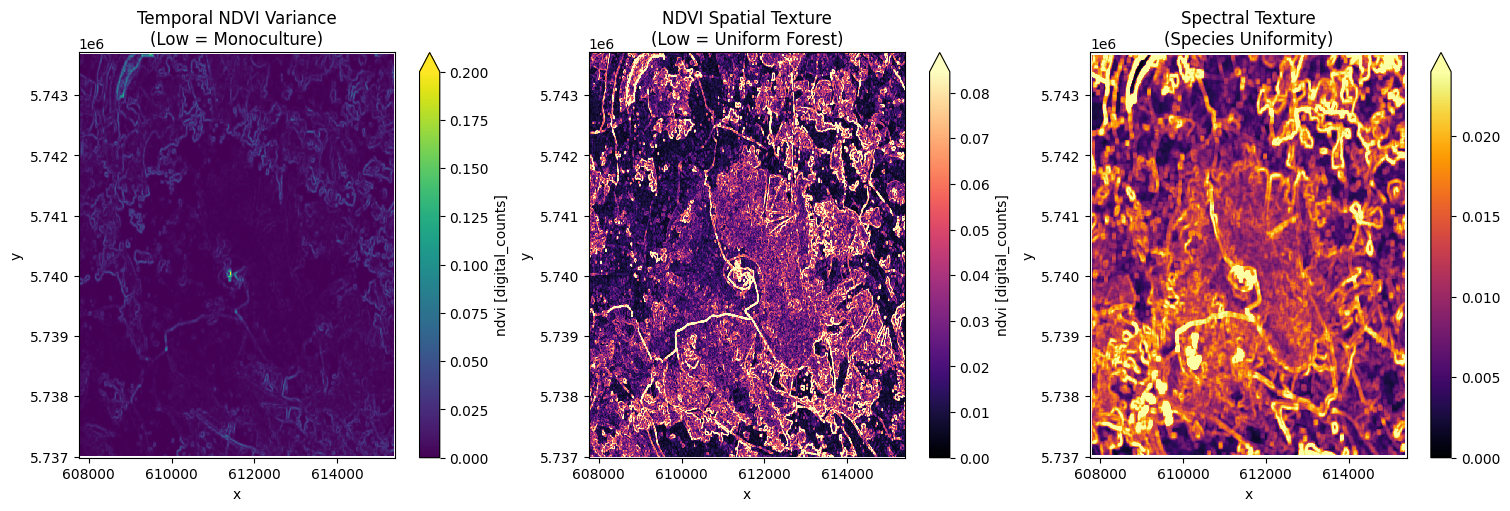

In [164]:
# --- Group: Variance & texture inputs ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

cv_combined.plot(ax=axes[0], cmap="viridis", vmin=0, vmax=0.2)
axes[0].set_title("Temporal NDVI Variance\n(Low = Monoculture)")

vmax_ndvi = ndvi_texture_ds.quantile(0.95).compute()
ndvi_texture_ds.plot(ax=axes[1], cmap="magma", vmin=0, vmax=vmax_ndvi)
axes[1].set_title("NDVI Spatial Texture\n(Low = Uniform Forest)")

vmax_spec = spectral_texture_ds.quantile(0.95).compute()
spectral_texture_ds.plot(ax=axes[2], cmap="inferno", vmin=0, vmax=vmax_spec)
axes[2].set_title("Spectral Texture\n(Species Uniformity)")

plt.show()

##### Monoculture Index & Candidates

In [154]:
mono_candidate = ndvi_texture_ds < ndvi_texture_ds.quantile(0.15)

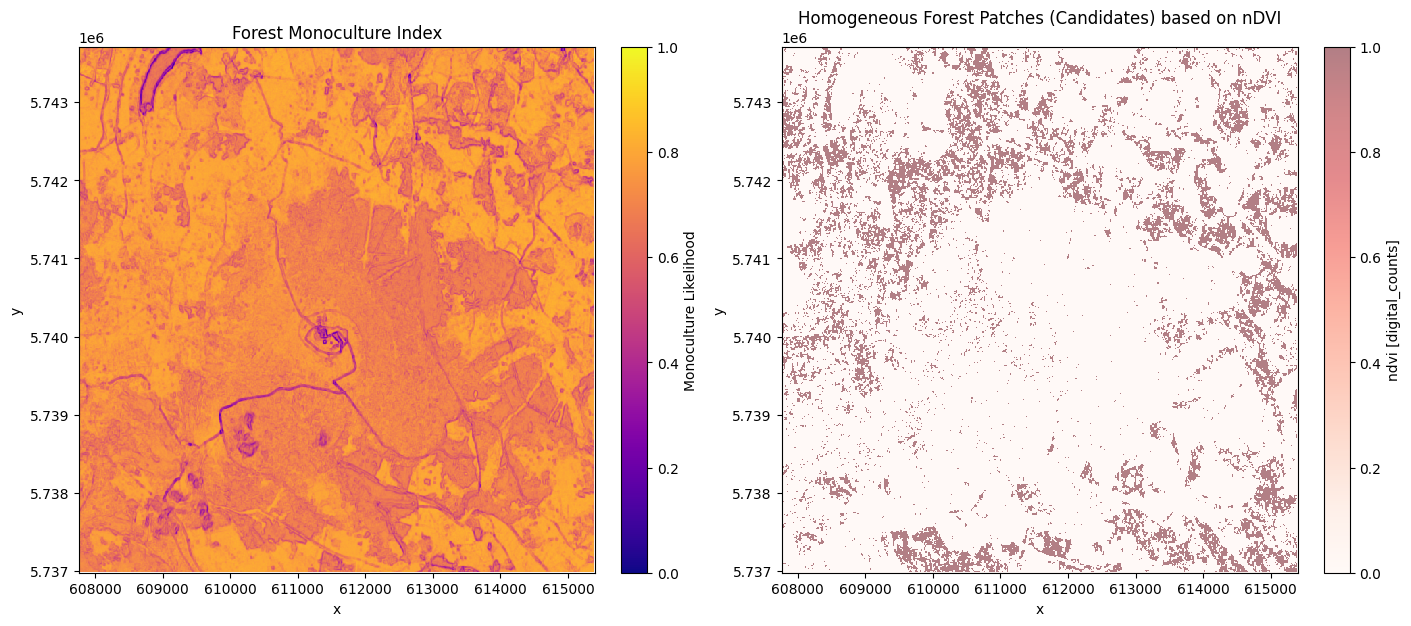

In [ ]:
# --- Group: Monoculture index & candidates ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

forest_mono_index_ds.plot(
    ax=axes[0],
    cmap="plasma",
    vmin=0,
    vmax=1,
    cbar_kwargs={"label": "Monoculture Likelihood"}
)
axes[0].set_title("Forest Monoculture Index")

mono_candidate.plot(ax=axes[1], cmap="Reds", alpha=0.5) # These are candidates only derived from texture
axes[1].set_title("Homogeneous Forest Patches (Candidates) based on nDVI")

plt.show()

##### Forest-Only Index

The identified outliers were mostly roads or clouds, which we have to remove to get a better scaling and idea for our data.

In [156]:
cutoff = 0.6 #Has to be defined by hand, because we can't automate what we see. Maybe it would be possibly, if we look at the density --> Technically these are outliers.
forest_only = forest_mono_index_ds.where(forest_mono_index_ds >= cutoff)

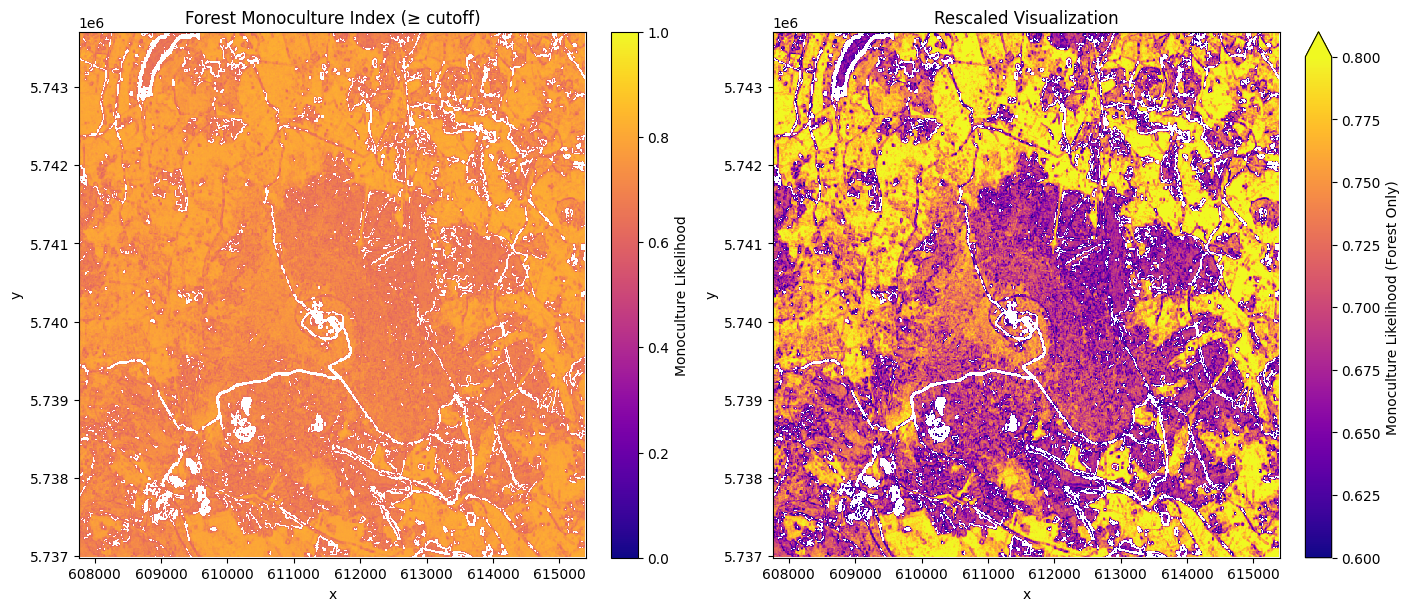

In [165]:
# --- Group: Forest-only monoculture index ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

forest_only.plot(
    ax=axes[0],
    cmap="plasma",
    vmin=0,
    vmax=1,
    cbar_kwargs={"label": "Monoculture Likelihood"}
)
axes[0].set_title("Forest Monoculture Index (≥ cutoff)")

forest_only.plot(
    ax=axes[1],
    cmap="plasma",
    vmin=cutoff,
    vmax=0.8,
    cbar_kwargs={"label": "Monoculture Likelihood (Forest Only)"}
)
axes[1].set_title("Rescaled Visualization")

plt.show()

##### 2018 vs. 2022

Nice! We can actually even see here, now with the rescaling, that there are patches of forest, which are more likely to be monoculture.

In [158]:
# Would be nice to get a mask that ignores roads and human built structures.
forest_mask = forest_only.notnull()

# Use mask on other datasets like this.
ndvi_forest_masked = ndvi.where(forest_mask)

Sanity check: Pathways are shown as extremely monoculture likely, so that checks out.
TODO: Remove these pixels with a mask?


In [159]:
forest_mono_index_ds_2018 = forest_monoculture_index(
    spectral_spatial_std(yearly_ds, year=2018),
    spectral_entropy(yearly_ds, year=2018),
    ndvi_texture(yearly_ds, year=2018),
)

forest_only_2018 = forest_mono_index_ds_2018.where(forest_mono_index_ds >= cutoff)

Text(0.5, 1.0, 'Monoculture Index (2018)')

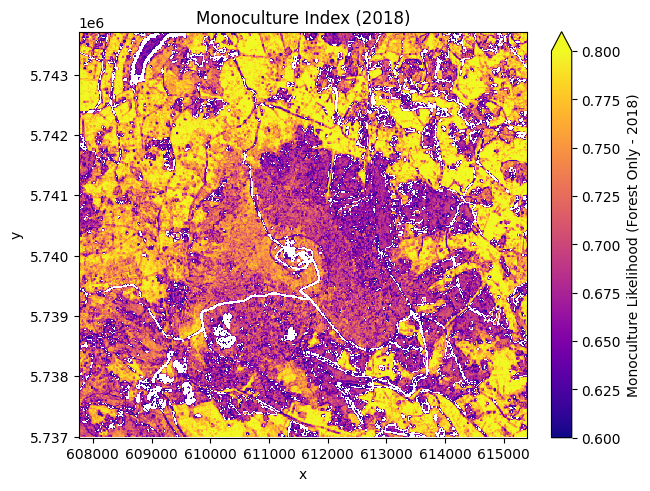

In [171]:
# --- Group: 2018 vs multi-year monoculture index ---
fig, axes = plt.subplots(1, 1, constrained_layout=True)

forest_only_2018.plot(
    ax=axes,
    cmap="plasma",
    vmin=cutoff,
    vmax=0.8,
    cbar_kwargs={"label": "Monoculture Likelihood (Forest Only - 2018)"}
)

axes.set_title("Monoculture Index (2018)")

## Results

##### Mono Vs. Non-Mono Outcome

Works! You can see, that even in the data, there isn't even enough forest gain to justify a schedule.
This means, that the area we identified as monoculture candidates were likely monoculture candidates as they all suffered substantial loss.

We can actually see that we get a meaningful distinction between monoculture areas, aswell as non-monoculture areas and in the percentage of forest loss happening there.

Let's also look at the area which is not classified as monoculture.

In [161]:
mono_mask_2018 = forest_only_2018 > 0.77 # This is taken from the example and varied a bit, to see what is considered a forest.

#Apply mask to NDVI from 2022, as this was the worst year.
ndvi_texture_2022 = ndvi_texture(yearly_ds, year=2022, window=1)

ndvi_with_monoculture_areas = forest_decline.where(mono_mask_2018)
ndvi_with_non_monoculture_areas = forest_decline.where(~mono_mask_2018)

In [162]:
def loss_percentage(masked_decline_da):
    loss_pixels = masked_decline_da.sum(["x", "y"])
    reference_pixels = masked_decline_da.notnull().sum(["x", "y"])
    return (loss_pixels / reference_pixels) * 100



loss_pct_mono = loss_percentage(ndvi_with_monoculture_areas)
loss_pct_non_mono = loss_percentage(ndvi_with_non_monoculture_areas)

loss_pct_mono_val = loss_pct_mono.compute().item()
loss_pct_non_mono_val = loss_pct_non_mono.compute().item()

print(
    f"Forest loss INSIDE 2018 monocultures (2018→2022): "
    f"{loss_pct_mono_val:.2f}%"
)

print(
    f"Forest loss OUTSIDE 2018 monocultures (2018→2022): "
    f"{loss_pct_non_mono_val:.2f}%"
)

Forest loss INSIDE 2018 monocultures (2018→2022): 73.77%
Forest loss OUTSIDE 2018 monocultures (2018→2022): 27.67%


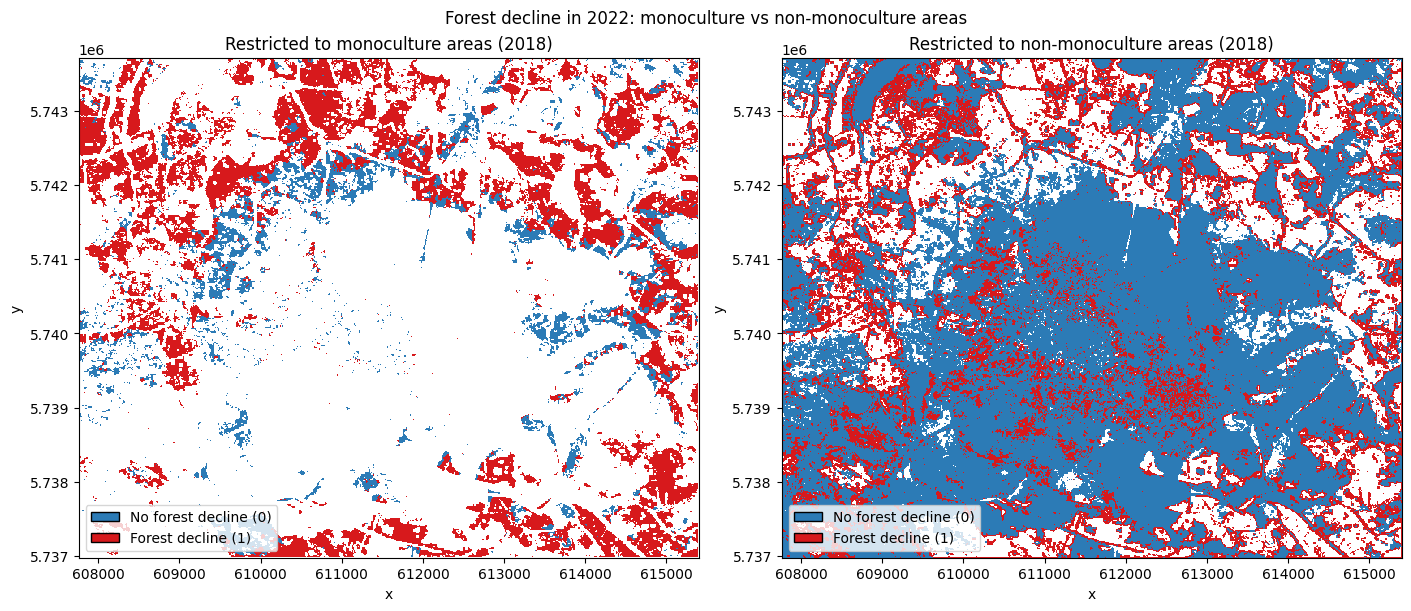

In [163]:
# Legend handles
legend_elements = [
    Patch(facecolor="#2c7bb6", edgecolor="black", label="No forest decline (0)"),
    Patch(facecolor="#d7191c", edgecolor="black", label="Forest decline (1)")
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

ndvi_with_monoculture_areas.plot(
    ax=axes[0],
    cmap=cmap,
    norm=norm,
    add_colorbar=False
)
axes[0].set_title("Restricted to monoculture areas (2018)")
axes[0].legend(
    handles=legend_elements,
    loc="lower left",
    frameon=True
)

ndvi_with_non_monoculture_areas.plot(
    ax=axes[1],
    cmap=cmap,
    norm=norm,
    add_colorbar=False
)
axes[1].set_title("Restricted to non-monoculture areas (2018)")
axes[1].legend(
    handles=legend_elements,
    loc="lower left",
    frameon=True
)

plt.suptitle("Forest decline in 2022: monoculture vs non-monoculture areas", fontsize=12)
plt.show()


#### Technology Results

- Zarr: Easily accessible, once the catalog was done. 
- Loading was quick
- Dask-Integration with Xarray allows for a nice extension of layers, e.g. an ndvi-layer or an scl-layer from a different source.
- XArray removes any barriers for using this data otherwise

### Reservations & Disclaimer

There might still be a bias, because we only tested it for the harz region, where we know that there is a lot of monoculture. Would be interesting to see, whether this is also doable. 
However, you can easily use the same principles on a better resolution and get more meaningful results for relatively low-cost computation. 

### Perspective

- Training a model with better imagery to calculate these clusters. 
- Better resolution 
- Change area of interest
- Make Cutoff dynamic? 